In [4]:
import pandas as pd
import numpy as np
path='https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DA0101EN-SkillsNetwork/labs/Data%20files/automobileEDA.csv'
df = pd.read_csv(path)
df.head()

#导入基于 Matplotlib 的高级统计可视化库，缩写为 sns。它封装了统计图形（回归图、箱线图、热力图等），代码更简洁。本 notebook 中用它画 regplot（回归散点图） 和 boxplot（箱线图）
import matplotlib.pyplot as plt
#Jupyter/IPython 魔法命令（不是 Python 语法），让图表直接内嵌显示在 notebook 单元格下方，而不是弹出独立窗口。注意它必须在已 import 后的独立一行执行
import seaborn as sns
%matplotlib inline

print(df.dtypes)

#Question1  查peak-rpm 的数据类型
print(df.dtypes)
print(df['peak-rpm'].dtype)

# df.corr() = 对数据表 df 中所有数值型列计算两两之间的皮尔逊相关系数矩阵：
# 输出是一个对称方阵N*N，对角线恒为 1（变量与自身完全相关）；
# 取值范围 [-1, 1]：越接近 1 越强正相关，越接近 -1 越强负相关，接近 0 则无线性关系；
# 例如在汽车数据集中可以读到：engine-size 与 price ≈ 0.87（强正相关，好预测变量），highway-mpg 与 price ≈ -0.70（负相关），peak-rpm ≈ -0.10（几乎无关，不适合预测价格）；
# 它只给出相关强度，不给出统计显著性——显著性（p 值）要靠后面第 5 节的 scipy.stats.pearsonr() 来检验。
# 一句话总结："1-1" 是单元格编号，这格代码的作用是生成整张表的相关系数总览矩阵，用来快速筛选哪些特征和车价有关系。
#默认 = 所有数值列、皮尔逊方法、逐对跳过 NaN，全自动，无需指定
#按照公式，把行和列排好然后计算
#                       bore     stroke     compression-ratio    horsepower
# bore                 1.000      ...           ...                ...
# stroke               ...        1.000         ...                ...
# compression-ratio    ...        ...           1.000              ...
# horsepower           ...        ...           ...                1.000
#如果指定了corr(x,y)，计算每一对列的相关系数时，单独为这一对列筛选数据，只保留两列同时有值的行。NaN 不是被整行扔掉，而是“按对跳过”。
#df.corr()  默认只能作用于int64和float64
#这个矩阵的作用是
# 筛选预测价格的候选特征，即这就是特征工程（Feature Selection）的第一步——在建模前先砍掉没用的变量，省计算、防噪声。
#决定可视化顺序，验证直觉，矩阵告诉你要画什么图：看到数值列和 price 相关系数高 → 用 regplot 画散点回归图确认线性关系；相关系数接近 0（如 peak-rpm）→ 画出来果然是水平线、点很散，图和数互相印证。反过来说：有了矩阵这个“总览”，你不用把 21 个变量两两画图（210 张图），只挑重要的看
#发现“替代变量”（变量间高度相关），length、width、curb-weight、wheel-base 之间互相都在 0.8 以上——车长、车宽、整备质量本质上是同一个“车身大小”概念；city-mpg 和 highway-mpg 相关约 0.97——几乎是重复信息。这提示两件事：建模时不需要全部塞进去（多重共线性会让回归系数不稳定），挑一两个代表即可；后续可以做降维（如 PCA）或把它们合并成“车身尺寸”这类综合指标。
#一句话总结：这张矩阵用一张表回答了三个问题——哪些变量能预测价格（选特征）、哪些变量本质重复（去冗余）、哪些关系值得画图细看（定可视化）。它是从“看数据”跨到“建模型”之间的桥梁


symboling              int64
normalized-losses      int64
make                     str
aspiration               str
num-of-doors             str
body-style               str
drive-wheels             str
engine-location          str
wheel-base           float64
length               float64
width                float64
height               float64
curb-weight            int64
engine-type              str
num-of-cylinders         str
engine-size            int64
fuel-system              str
bore                 float64
stroke               float64
compression-ratio    float64
horsepower           float64
peak-rpm             float64
city-mpg               int64
highway-mpg            int64
price                float64
city-L/100km         float64
horsepower-binned        str
diesel                 int64
gas                    int64
dtype: object
symboling              int64
normalized-losses      int64
make                     str
aspiration               str
num-of-doors             str


,peak-rpm,price
peak-rpm,1.000000,-0.101616
price,-0.101616,1.000000


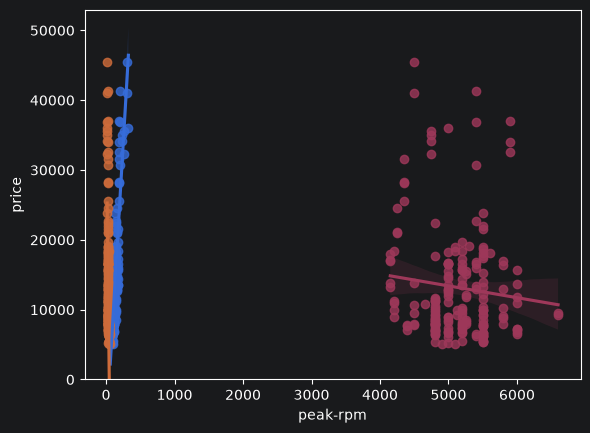

In [5]:
#bore/stroke/compression-ratio/horsepower 的相关矩阵
df[['bore','stroke','compression-ratio','horsepower']].corr()
#                       bore     stroke     compression-ratio    horsepower
# bore                 1.000      ...           ...                ...
# stroke               ...        1.000         ...                ...
# compression-ratio    ...        ...           1.000              ...
# horsepower           ...        ...           ...                1.000


# regplot 自动做两件事：
# 把 df 中每一辆车画成一个散点（横坐标 = 该车 engine-size，纵坐标 = 该车 price）；
# 对这些点拟合一条最小二乘回归线并画出来，线两侧的浅色阴影是回归线的置信区间（95% CI，阴影越窄说明估计越可靠、点越集中）。
sns.regplot(x="engine-size", y="price", data=df)
#用 Matplotlib 把 y 轴下限设为 0（上限 留空 = 不限制，自动）。
# 价格不可能为负，强制从 0 开始让图符合物理意义；
# 防止 Seaborn 自动缩放时 y 轴从某个非零值（如 5000）开始，那样会在视觉上夸大回归线的倾斜程度，误导读者。
#  注意语法：plt.ylim(0,) 里的逗号必须写，因为它等价于 plt.ylim(bottom=0)——这是“传一个元组 (0, None)”的简写，忘了逗号会报错。
plt.ylim(0,)
# price
#   │                        ·  ·
#   │                    · ···  ·
#   │                 ······
#   │            ·····
#   │        ····
#   │    ····
#   │ ···
#   └──────────────────────── engine-size
# 回归线接近完美的对角线，向上倾斜 → engine-size 与 price 是强正相关；
# 点比较贴近回归线 → 线性关系可靠；
# 这正是相关系数 r ≈ 0.87 的可视化呈现——下一格代码 df[["engine-size","price"]].corr() 用数字证实了图上看到的规律。
# 演示了如何用 regplot 目测判断一个变量值不值得用来预测价格——engine-size 就是这样被确认为最强预测变量的。
#第一行画“发动机尺寸 vs 价格”的散点+拟合线，第二行把纵轴钉在 0 起点；图上向右上的直线直观证明了发动机越大车越贵。

#先画图看，然后再通过corr()验证一下
df[["engine-size", "price"]].corr()

sns.regplot(x="highway-mpg", y="price", data=df)
df[['highway-mpg', 'price']].corr()

sns.regplot(x="peak-rpm", y="price", data=df)
df[['peak-rpm','price']].corr()



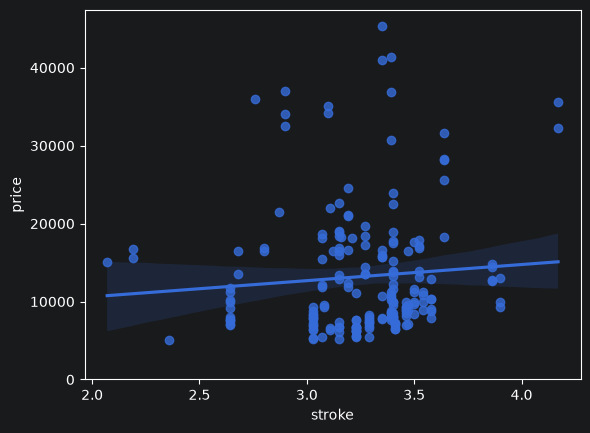

C:\Users\A\AppData\Local\Temp\ipykernel_30224\1475451630.py:51: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include=['object'])


TypeError: dtype 'str' does not support operation 'mean'

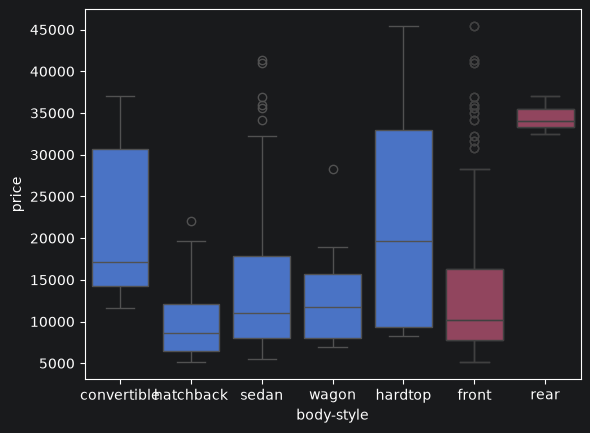

In [6]:
#Q3 stroke 与 price 的相关系数
df[['stroke','price']].corr()

#Q3是否线性关系？用 regplot() 验证
sns.regplot(x='stroke', y='price', data=df)
plt.ylim(0,)
plt.show()

#必须"数值 + 图形"双证据：先由 |r|≈0.08 作出判断，再用 regplot 佐证散点极度分散、回归线近乎水平。

# 数值 vs 数值	regplot	engine-size vs price
# 分类 vs 数值	boxplot	本格：body-style vs price
#画一张箱线图，用来研究分类变量 body-style（车身样式）对数值变量 price（价格）的影响——这是 notebook "Categorical Variables" 小节的第一张图。
#和 regplot 的关键区别：x 这里放的是类别而不是连续数值，所以不再是一条回归线，而是每个类别一根箱子。
    #   ┌─┐ ← 最大值（须线外为离群点 ○）
    #   │ │
    # ┌─┴─┴─┐ ← 上四分位数 Q3 (75%)
    # │     │
    # ├─────┤ ← 中位数 Median (50%)，箱内那条线
    # │     │
    # └─┬─┬─┘ ← 下四分位数 Q1 (25%)
    #   │ │
    #   └─┘ ← 最小值
# 不同类别的箱子重叠严重 → 类别对价格区分度低 → 差的预测变量（如 body-style）；
# 不同类别的箱子几乎不重叠 → 区分度高 → 好的预测变量（如 engine-location、drive-wheels）。
#一句话总结：这格代码把车按 5 种车身样式分组，各画一个价格分布箱——结果箱子大量重叠，说明“车身样式”这个分类特征对预测车价帮助不大。


#这就是箱线图读图的通用准则：分离 = 有区分度 = 有预测价值；重叠 = 区分不了 = 没用。
#  5 个车身样式的箱子高度重叠严重（尤其是 sedan、hatchback、wagon 的价格区间几乎叠在一起，中位数也差不多）→ 说明知道车身样式，并不能很好地推断价格；
sns.boxplot(x="body-style", y="price", data=df)

# 含义：只要知道引擎在哪，就能大致区分这车是贵还是便宜——后置引擎的车（如保时捷 911 这类跑车）普遍贵，前置的普通家用车便宜；
sns.boxplot(x="engine-location", y="price", data=df)

sns.boxplot(x="engine-location", y="price", data=df)

# 图	                     箱子关系	            样本量	                    结论
# body-style vs price	        大量重叠	        均衡	                  ✗ 不适合
# engine-location vs price	     明显分离	    严重不均（rear 仅 3）	   ⚠️ 不可下结论
# drive-wheels vs price（本格）	  明显不同	      较均衡	                    ✓ 好预测变量

# 一句话总结：代码画三种驱动方式的价格箱线图，发现后驱车明显更贵且样本量充足——drive-wheels 是本数据集中少数被确认“靠谱”的分类特征，后面第 4 节的 groupby 平均价将用数字再次验证它。


# 写法	统计哪些列	行为
# df.describe()	只统计数值列（int64/float64），object 列直接被丢弃	默认行为
# df.describe(include=['object'])	只统计 object 列	数值列被排除
# df.describe(include='all')	数值列 + object 列全部要	一个都不落下
df.describe()
df.describe(include=['object'])
# 代码能跑，结果也对，只是 pandas 在提醒你 ——「你写的 include=['object'] 这种写法在未来版本会失效，趁早改」。
#count	非空值的数量 unique是该列有多少个不同的类别（去重后的取值个数） top	出现次数最多的类别（众数） freq	众数出现了多少次
#              make  fuel-type  aspiration  num-of-doors  body-style  drive-wheels  engine-location
# count         201        201         201           201         201           201              201
# unique         22          2           2             2           5             3                2
# top          toyota        gas         std          four      sedan           rwd            front
# freq           31        180         159           114          94           76              198
#所以带有include=object，只能统计这些内容

df['drive-wheels'].value_counts() #这行代码对 drive-wheels（驱动轮类型）列进行频次统计，统计每种驱动方式各有多少辆车。
#对 drive-wheels（驱动轮类型）列做频次统计后，将结果从 Series 转换为 DataFrame。
df['drive-wheels'].value_counts().to_frame()
#               drive-wheels
# fwd                  118
# rwd                   75
# 4wd                    8

drive_wheels_counts = df['drive-wheels'].value_counts().to_frame()
drive_wheels_counts.rename(columns={'drive-wheels': 'value_counts'}, inplace=True)
drive_wheels_counts

#设置索引名称
drive_wheels_counts.index.name = 'drive-wheels'
drive_wheels_counts
# drive-wheels      drive-wheels
# fwd                  118
# rwd                   75
# 4wd                    8

#对engine-location，再做一次这种操作
engine_loc_counts = df['engine-location'].value_counts().to_frame()
engine_loc_counts.rename(columns={'engine-location': 'value_counts'}, inplace=True)
engine_loc_counts.index.name = 'engine-location'
engine_loc_counts.head(10)

#获取 drive-wheels（驱动轮类型）列中所有不重复的取值，返回一个 NumPy 数组。
df['drive-wheels'].unique()
df_group_one = df[['drive-wheels','body-style','price']]

#按驱动方式分组求平均价格 每一组都求平均价格 as_index=False：分组键不作为索引，而是保留为普通数据列；as_index=True（默认）	drive-wheels 变成行索引
#用 as_index=False 的好处：结果更像普通表格，方便后续用列名引用（如 .pivot()、.merge()），这与第 4 节后面做透视表的需要相呼应
df_group_one = df_group_one.groupby(['drive-wheels'],as_index=False).mean()
df_group_one

# as_index=False:                as_index=True:
#   drive-wheels    price         price
# 0  fwd          10001.4        drive-wheels
# 1  rwd          19903.6        fwd    10001.4
# 2  4wd          13518.2        rwd    19903.6
#                                4wd    13518.2

#此时的df_group_one，从三个列，变成两列了，因为其中一列变成分组条件了
#   drive-wheels         price
# 0         fwd   10001.431373
# 1         rwd   19903.614458
# 2         4wd   13518.222222

In [7]:

#     drive-wheels  body-style        price
# 0          4wd  hatchback  10311.764706
# 1          fwd  hatchback   9409.006897
# 2          rwd  sedan      18519.700000

df_gptest = df[['drive-wheels','body-style','price']]
grouped_test1 = df_gptest.groupby(['drive-wheels','body-style'],as_index=False).mean()
grouped_test1

#作用是把分组均值结果重排成透视表，为后面的热力图可视化做准备
# index='drive-wheels'	该列的每个唯一值变成透视表的行（rwd / fwd / 4wd 共 3 行）
#columns='body-style'	该列的每个唯一值变成透视表的列（convertible / hatchback / sedan / wagon / hardtop 共 5 列）
#取两列，一列变行，一列变列
# values（未指定）	—	自动对剩余的数值列（只有 price）取值填入单元格;默认这里只有一行，所以只取price
grouped_pivot = grouped_test1.pivot(index='drive-wheels',columns='body-style')
grouped_pivot

#               price
# body-style    convertible     hardtop    hatchback        sedan       wagon
# drive-wheels
# 4wd                NaN          NaN  10311.764706  12647.263158  NaN
# fwd                NaN   11894.5000   9409.006897   9811.800000  NaN
# rwd         23633.000000  22143.9250  10363.440000  24543.666667  NaN


#缺失数据本身是个复杂问题，这里填 0 只是为了让后面的热力图能画出来。这里是将Nan填为0
grouped_pivot = grouped_pivot.fillna(0) #fill missing values with 0
grouped_pivot
#pivot 本身不产生任何新信息，它纯粹是为了可视化服务的重排
# 长表适合给 pandas 读，宽表适合给人看和给 plt.pcolor()（第 323、331 行）画热力图
# 这两行代码把"按驱动方式 × 车身样式分组的平均价格"长表转置成行=drive-wheels、列=body-style 的二维透视表（类似 Excel 交叉表），暴露出组合缺失的 NaN 单元格，为下一步 fillna(0) 和热力图绘制铺路




price                                            \
body-style   convertible       hardtop     hatchback         sedan   
drive-wheels                                                         
4wd                  0.0      0.000000   7603.000000  12647.333333   
fwd              11595.0   8249.000000   8396.387755   9811.800000   
rwd              23949.6  24202.714286  14337.777778  21711.833333   

                            
body-style           wagon  
drive-wheels                
4wd            9095.750000  
fwd            9997.333333  
rwd           16994.222222

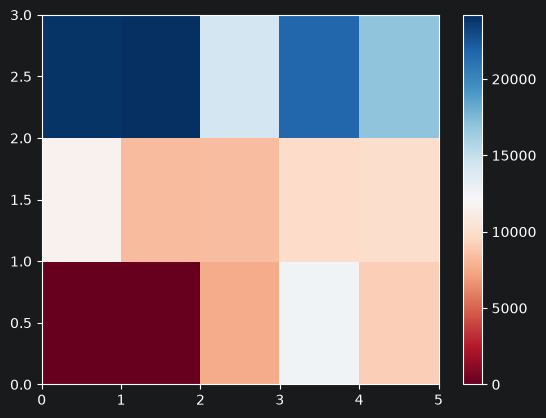

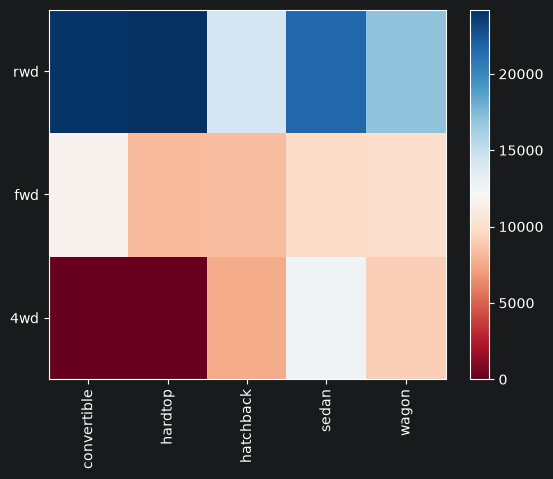

The Pearson Correlation Coefficient is 0.584641822265508  with a P-value of P = 8.076488270732847e-20
The Pearson Correlation Coefficient is 0.8095745670036562  with a P-value of P =  6.369057428259638e-48
The Pearson Correlation Coefficient is 0.6906283804483639  with a P-value of P =  8.016477466159293e-30
The Pearson Correlation Coefficient is 0.7512653440522675  with a P-value of P = 9.200335510480589e-38
The Pearson Correlation Coefficient is 0.8344145257702844  with a P-value of P =  2.189577238893924e-53


In [8]:
df_gptest2 = df[['body-style','price']]
grouped_test_bodystyle = df_gptest2.groupby(['body-style'], as_index=False).mean()
grouped_test_bodystyle

import matplotlib.pyplot as plt
%matplotlib inline

# pcolor（pseudo-color，伪彩色图）把 DataFrame 当作一个数值矩阵，每个单元格画成一个色块，颜色深浅由数值大小决定；
#这里矩阵是 3 行（drive-wheels）× 5 列（body-style），单元格里存的是平均价格；cmap='RdBu' 指定红蓝配色：数值越大越红、越小越蓝——所以贵的组合呈红色，便宜或缺失（填了 0）的组合呈深蓝色。
# plt.pcolor(...) 函数式，默认 0、1、2 序号，不可读，差，画完就结束
plt.pcolor(grouped_pivot, cmap='RdBu')
# 在图右侧加一条颜色图例，把"颜色 ↔ 价格数值"的对应关系标出来，没有它图上的红蓝就无法量化。
plt.colorbar()
# 渲染并显示图形。在 Jupyter 中由于前面已有 %matplotlib inline，不加它通常也能显示，但这是标准的收尾写法。
plt.show()


# 同时创建两个对象并解包：
# fig（Figure）：整张画布，是所有元素的顶层容器； ax（Axes）：画布上的一块坐标系/绘图区，之后所有绘图操作都作用在它上面。 subplots() 不带参数时就是"1 张画布 + 1 个坐标系"。
fig, ax = plt.subplots()
# 和上一段的 plt.pcolor 内容相同：把透视表画成红蓝热力图（红=高价，蓝=低价/缺失填 0）；区别在于：调用者是 ax 而不是 plt，图画在指定的坐标系里；
# 返回值被存进了 im——它是一个 QuadMesh 对象（所有色块的集合）。这个对象非常重要，最后一行 fig.colorbar(im) 靠它才知道颜色条要按什么数值范围来标刻度。
im = ax.pcolor(grouped_pivot, cmap='RdBu')


#先看一下grouped_pivot的结构
#               price                                    ← 一级列（columns 第 0 层）
# body-style convertible  hardtop  hatchback ...         ← 二级列（columns 第 1 层）
# drive-wheels
# 4wd                 0.0       0.0  10311.76 ...
# fwd                 0.0   11894.5   9409.00 ...
# rwd           23633.00   22143.9  10363.44 ...

#grouped_pivot.columns，取出表头（即列名），这里标准叫法叫多级列索引（MultiIndex）
#有两层
# levels[0] → ['price']（未指定 values 参数，剩余数值列自动套上去的）
# levels[1] → ['convertible', 'hardtop', 'hatchback', 'sedan', 'wagon']（body-style 的取值）
row_labels = grouped_pivot.columns.levels[1]
# 行索引：grouped_pivot.index → Index(['4wd', 'fwd', 'rwd'], name='drive-wheels')
col_labels = grouped_pivot.index

# 这两行的作用是把刻度线移到每个色块的正中央，为下一行贴标签做准备。
#shape[0] 是行（取行数）、shape[1] 是列（取列数），顺序和数学里矩阵"m 行 n 列"的写法一致。grouped_pivot是3行5列
# grouped_pivot.shape[1]	5	透视表有 5 列（5 种 body-style）
#np.arange(5)	[0, 1, 2, 3, 4]	生成 0~4 的整数序列
#np.arange 是 NumPy 里的一个函数，用来生成等差数组（即按固定步长排列的一串数字）。步长默认为1
#np.arange(grouped_pivot.shape[1]) + 0.5 代表这个等差数组，所有元素右移半格，grouped_pivot.shape[1]这个值是5，即np.arange(5)；np.arange(1, 10, 2) # array([1, 3, 5, 7, 9])   步长为2
#minor=False 是什么意思？matplotlib 的刻度分两种：major（主刻度）：默认显示的大刻度；minor（次刻度）：更细的小刻度。
# minor=False 明确表示"我设置的是主刻度"。这里写出来主要是因为下一行 set_xticklabels(..., minor=False) 也要用同样参数配对——告诉 matplotlib"这些标签对应主刻度"，防止和次刻度混淆。
# ax.set_xticks(...)	—	把 X 轴刻度设在这些位置上；ax.set_yticks()同理
ax.set_xticks(np.arange(grouped_pivot.shape[1]) + 0.5, minor=False)
ax.set_yticks(np.arange(grouped_pivot.shape[0]) + 0.5, minor=False)


# 把 X 轴各刻度的显示文字依次设为 row_labels（body-style 名称）；
# 因为上一步 set_xticks 设了 5 个位置，所以按顺序对应
# 位置:  0.5      1.5      2.5     3.5    4.5
# 文字:  convertible  hardtop  hatchback  sedan  wagon
# 从此 X 轴下方显示的不再是 0 1 2 3 4，而是 5 种车身样式的名字。
#Y轴也一样
# 位置:  0.5    1.5    2.5
# 文字:  4wd    fwd    rwd
# set_xticks 和 set_xticklabels 必须成对使用，且数量一致
ax.set_xticklabels(row_labels, minor=False)
ax.set_yticklabels(col_labels, minor=False)

# rotation=90 把 X 轴刻度标签旋转 90 度，即竖着显示；
# 原因如注释所说：convertible、hatchback 这些单词较长，如果横着排，5 个标签会互相重叠成一团；竖排后每个标签只占一列的宽度，清晰可读；
# 注意这里用的是 plt.（pyplot 函数式），和前面 ax.set_xticklabels(...) 混用了两种接口——效果相同，pyplot 的 plt.xticks 会作用于当前活跃的坐标系（就是 ax）。
# 如果想保持纯 OOP 风格，等价写法是 ax.tick_params(axis='x', rotation=90) 或 ax.set_xticklabels(row_labels, rotation=90)。
plt.xticks(rotation=90)

# 在图右侧加一条竖直颜色条，标出“颜色 ↔ 数值”的对应关系（价格从低到高 = 从蓝到红）；
# 关键在参数 im：它是前面 ax.pcolor(...) 的返回值（QuadMesh 对象）。colorbar 靠它才知道：
# 这张图的颜色映射范围是什么（最小值 0 到最大值约 23633）；
# 用的是哪种 cmap（RdBu）；
# 这就是为什么当初画图时要把返回值存进 im——如果直接写 fig.colorbar()（旧版写法靠“最近一张图"的隐式状态），在多图场景下容易挂错图例。传 im 是明确、稳妥的写法。
fig.colorbar(im)  #fig是之前定义的画布对象，在画布中添加图例
# 触发渲染，把 fig 画布真正显示出来；
# 在 Jupyter 中因为之前有 %matplotlib inline，单元格执行完本会自动显示图，plt.show() 严格说可省，但它是脚本环境的通用标准写法，写上无害。
# 什么时候用 plt，什么时候用 ax 简单图随手用 plt（快速预览、一次性图表、不想改细节），需要精细控制或画多图时用 ax（要精细调整图的部件——本例就是典型：要挪刻度位置、换标签文字、转角度。）。
plt.show()

# df.corr()

# SciPy（读作"sigh-pie"）是建立在 NumPy 之上的科学计算库，stats 是它的统计分析子模块，包含几百种统计检验、分布和函数；
# 写法是 from 库 import 子模块——因为 SciPy 很大，只把需要的 stats 拿进来，之后直接用 stats.xxx 调用，而不用写完整的 scipy.stats.xxx。
from scipy import stats

# stats.pearsonr(x, y) 一次返回两个值：
# 返回值	                         含义	                      例子（wheel-base vs price）
# pearson_coef	皮尔逊相关系数，范围 [-1, 1]，衡量线性关系强弱和方向	≈ 0.585
# p_value	p 值，衡量这个相关性是否统计显著（是不是碰巧出现的）	< 0.001
pearson_coef, p_value = stats.pearsonr(df['wheel-base'], df['price'])
print("The Pearson Correlation Coefficient is", pearson_coef, " with a P-value of P =", p_value)

# 方向：正相关
# r>0 → 轴距越长，车价总体越高。散点图上拟合线是向上倾斜的。

# 教材按 |r| 的常见划分：
# |r| 区间	线性关系
# 0 ~ 0.2	几乎没有
# 0.2 ~ 0.4	弱
# 0.4 ~ 0.6	中等 ← 0.585 在这里
# 0.6 ~ 0.8	中强
# 0.8 ~ 1.0	强

#                               df.corr()	                                                  stats.pearsonr(x, y)
# 范围	一次算出所有数值列两两组合的完整相关矩阵（第 92 行 df.corr() 一次给出二十多列的矩阵）	一次只算一对变量
# p 值	❌ 不给 p 值，只有系数——你无法判断 0.585 是真相关还是运气	                        ✅ 同时返回 p 值，能做显著性判断
# 返回类型	DataFrame（对称矩阵，对角线恒为 1）	                                             元组 (coef, p_value)，可直接解包
# 一句话总结：两者算的是同一个皮尔逊系数，df.corr() 是“批量全景工具”（矩阵、无 p 值），stats.pearsonr 是“单对深挖工具”（系数 + 显著性检验）——教材先用前者扫出候选变量，再用后者逐一验证可信度，是标准的 EDA 相关性分析流程
# p值的作用（大样本和小样本的区别），这像“抓牌作弊”的推理——如果一个人连续 10 把摸到好牌（p 值极小），你敢说“纯属运气”吗？运气解释不通时，只剩一个结论：牌技有问题（真实关系存在）。
pearson_coef, p_value = stats.pearsonr(df['horsepower'], df['price'])
print("The Pearson Correlation Coefficient is", pearson_coef, " with a P-value of P = ", p_value)

pearson_coef, p_value = stats.pearsonr(df['length'], df['price'])
print("The Pearson Correlation Coefficient is", pearson_coef, " with a P-value of P = ", p_value)

pearson_coef, p_value = stats.pearsonr(df['width'], df['price'])
print("The Pearson Correlation Coefficient is", pearson_coef, " with a P-value of P =", p_value )

pearson_coef, p_value = stats.pearsonr(df['curb-weight'], df['price'])
print( "The Pearson Correlation Coefficient is", pearson_coef, " with a P-value of P = ", p_value)


# 算出 r = 0.585
#       │
#       ▼
# 显著性检验（p 值）
#       │
#    ┌──┴───┐
#    ▼      ▼
# p 很小    p 很大
#    │      │
# 真相关    可能只是运气
# → 入选     → 淘汰，别当特征用